[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-3/streaming-interruption.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239464-lesson-1-streaming)

# Streaming

## Review

모듈 2에서는 그래프 상태와 메모리를 맞춤 설정하는 몇 가지 방법을 다루었습니다.
 
우리는 장기적인 대화를 유지할 수 있는 외부 메모리를 가진 챗봇을 구축했습니다. 

## Goals

이 모듈에서는 메모리를 기반으로 하여 사용자가 다양한 방식으로 그래프와 직접 상호작용할 수 있도록 하는 `인간 개입형(human-in-the-loop)`에 대해 심층적으로 살펴보겠습니다.

`인간 개입형`을 위한 기반을 마련하기 위해, 먼저 실행 과정 전반에 걸쳐 그래프 출력(예: 노드 상태 또는 채팅 모델 토큰)을 시각화하는 여러 방법을 제공하는 스트리밍에 대해 살펴보겠습니다.

In [ ]:
# %%capture --no-stderr
# %pip install --quiet -U langgraph langchain_openai langgraph_sdk

## Streaming

LangGraph는 [스트리밍에 대한 최상위 지원](https://docs.langchain.com/oss/python/langgraph/streaming)을 바탕으로 구축되었습니다.

모듈 2에서 채팅봇을 설정하고, 실행 중 그래프의 출력을 스트리밍하는 다양한 방법을 보여드리겠습니다. 

In [1]:
# import os, getpass

# def _set_env(var: str):
#     if not os.environ.get(var):
#         os.environ[var] = getpass.getpass(f"{var}: ")

# _set_env("OPENAI_API_KEY")

from dotenv import load_dotenv

load_dotenv("../../.env")

True

토큰 단위 스트리밍을 활성화하기 위해 `call_model`과 함께 `RunnableConfig`를 사용합니다. 이는 [Python 3.11 미만 버전에서만 필요합니다](https://langchain-ai.github.io/langgraph/how-tos/streaming-tokens/). CoLab에서 이 노트북을 실행할 경우 Python 3.x가 사용되므로 포함시켰습니다. 

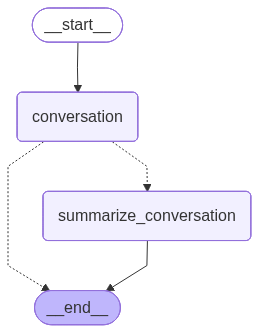

In [2]:
from IPython.display import Image, display
from typing import Literal

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

# LLM
model = ChatOpenAI(model="gpt-4o", temperature=0) 

# State 
class State(MessagesState):
    summary: str

# Define the logic to call the model
def call_model(state: State, config: RunnableConfig):
    
    # Get summary if it exists
    summary = state.get("summary", "")

    # If there is summary, then we add it
    if summary:
        
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    
    else:
        messages = state["messages"]
    
    response = model.invoke(messages, config)
    return {"messages": response}

def summarize_conversation(state: State):
    
    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt 
    if summary:
        
        # A summary already exists
        summary_message = (
            f"지금까지의 대화 요약은 다음과 같습니다:: {summary}\n\n"
            "위의 새로운 메시지를 고려하여 요약을 확장하십시오:"
        )
        
    else:
        summary_message = "위의 대화 내용을 요약하세요.:"

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# Determine whether to end or summarize the conversation
def should_continue(state: State)-> Literal ["summarize_conversation",END]:
    
    """Return the next node to execute."""
    
    messages = state["messages"]
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
    
    # Otherwise we can just end
    return END

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

### Streaming full state

이제 그래프 상태를 [스트리밍하는 방법](https://docs.langchain.com/oss/python/langgraph/streaming#supported-stream-modes)에 대해 이야기해 보겠습니다.

`.stream`과 `.astream`은 결과를 스트리밍으로 반환하는 동기 및 비동기 메서드입니다. 
 
LangGraph는 그래프 상태에 대해 몇 가지 [다양한 스트리밍 모드](https://docs.langchain.com/oss/python/langgraph/streaming#stream-graph-state)를 지원합니다.
 
* `values`: 각 노드 호출 후 그래프의 전체 상태를 스트리밍합니다.
* `updates`: 각 노드 호출 후 그래프 상태의 업데이트를 스트리밍합니다.

![values_vs_updates.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbaf892d24625a201744e5_streaming1.png)

`stream_mode=“updates”`를 살펴보겠습니다.

`updates`로 스트리밍하기 때문에 그래프 내 노드가 실행된 후 상태 업데이트만 확인할 수 있습니다.

각 `chunk`는 `node_name`을 키로, 업데이트된 상태를 값으로 하는 딕셔너리입니다.

In [3]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
for chunk in graph.stream({"messages": [HumanMessage(content="안녕, 내이름은 유광명이야.")]}, config, stream_mode="updates"):
    print(chunk)

{'conversation': {'messages': AIMessage(content='안녕하세요, 유광명님! 만나서 반갑습니다. 오늘 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 19, 'total_tokens': 41, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_ed36a96f3d', 'id': 'chatcmpl-DCDQ7Zbt8IPDbCYwogPn2NxwUMNCQ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c87bd-e4db-7c11-bc56-a2f55e8ae1a7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 22, 'total_tokens': 41, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})}}


Let's now just print the state update.

In [4]:
# Start conversation
for chunk in graph.stream({"messages": [HumanMessage(content="안녕, 내이름은 유광명이야.")]}, config, stream_mode="updates"):
    chunk['conversation']["messages"].pretty_print()

================================== Ai Message ==================================

안녕하세요, 유광명님! 만나서 반갑습니다. 어떻게 도와드릴까요?


이제 `stream_mode=“values”`를 확인할 수 있습니다.

이는 `conversation` 노드가 호출된 후 그래프의 `전체 상태`입니다.

In [5]:
# Start conversation, again
config = {"configurable": {"thread_id": "2"}}

# Start conversation
input_message = HumanMessage(content="hi! I'm Lance")
for event in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    for m in event['messages']:
        m.pretty_print()
    print("---"*25)

================================ Human Message =================================

hi! I'm Lance
---------------------------------------------------------------------------
================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

Hello Lance! How can I assist you today?
---------------------------------------------------------------------------


### Streaming tokens

우리는 종종 그래프 상태 이상의 것을 스트리밍하고 싶어합니다.

특히 채팅 모델 호출에서는 생성되는 토큰을 실시간으로 스트리밍하는 것이 일반적입니다.

이를 위해 [`.astream_events` 메서드](https://docs.langchain.com/oss/python/langchain/models#advanced-streaming-topics:streaming-events)를 사용할 수 있으며, 이 메서드는 노드 내부에서 발생하는 이벤트를 실시간으로 스트리밍합니다!

각 이벤트는 몇 가지 키를 가진 딕셔너리입니다:
 
* `event`: 발생 중인 이벤트의 유형입니다.
* `name`: 이벤트의 이름입니다.
* `data`: 이벤트와 연관된 데이터입니다.
* `metadata`: 이벤트를 발생시킨 노드인 `langgraph_node`를 포함합니다.

자세히 살펴보겠습니다.

In [6]:
config = {"configurable": {"thread_id": "3"}}
input_message = HumanMessage(content="LA Dodgers 팀에 대해서 알려줘.")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    print(f"Node: {event['metadata'].get('langgraph_node','')}. Type: {event['event']}. Name: {event['name']}")

Node: . Type: on_chain_start. Name: LangGraph
Node: conversation. Type: on_chain_start. Name: conversation
Node: conversation. Type: on_chat_model_start. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. N

핵심은 그래프 내 채팅 모델의 토큰이 `on_chat_model_stream` 유형을 가지는 점입니다.

`event[‘metadata’][‘langgraph_node’]`를 사용해 스트리밍할 노드를 선택할 수 있습니다.

또한 `event[‘data’]`를 통해 각 이벤트의 실제 데이터를 얻을 수 있으며, 이 경우 `AIMessageChunk`입니다. 

In [7]:
node_to_stream = 'conversation'
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="LA Dodgers 팀에 대해서 알려줘.")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        print(event["data"])

{'chunk': AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019c87c0-90be-7923-b9c9-5c27e88c9120', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content='LA', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019c87c0-90be-7923-b9c9-5c27e88c9120', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=' 다', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019c87c0-90be-7923-b9c9-5c27e88c9120', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content='저', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019c87c0-90be-7923-b9c9-5c27e88c9120', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content='스', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019

As you see above, just use the `chunk` key to get the `AIMessageChunk`.

In [8]:
config = {"configurable": {"thread_id": "5"}}
input_message = HumanMessage(content="LA Dodgers 팀에 대해서 알려줘.")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        data = event["data"]
        print(data["chunk"].content, end="|")

|LA| 다|저|스|(L|os| Angeles| Dodgers|)는| 미국| 메|이|저| 리|그| 베|이스|볼|(|ML|B|)에| 소|속|된| 프로| 야|구| 팀|으로|,| 내|셔|널| 리|그| 서|부| 지|구|에| 속|해| 있습니다|.| 팀|은| 캘|리|포|니|아|주| 로|스|앤|젤|레|스를| 연|고|지|로| 하고| 있으며|,| 홈|구|장은| 다|저| 스타|디|움|(D|od|ger| Stadium|)|입니다|.| 다|저|스|는| |188|3|년에| 뉴|욕| 브|루|클|린|에서| 창|단|되|었|으며|,| |195|8|년에| 로|스|앤|젤|레|스로| 이전|했습니다|.

|다|저|스|는| 메|이|저| 리|그|에서| 가장| 성공|적인| 팀| 중| 하나|로|,| 여러| 차|례| 월|드| 시|리즈| 우|승|을| 차|지|했습니다|.| 팀|은| 뛰|어난| 선수|들과| 전|설|적인| 감독|들을| 배|출|했|으며|,| 특히| 재|키| 로|빈|슨|(J|ack|ie| Robinson|)이| |194|7|년에| 다|저|스|에서| 데|뷔|하면서| 인|종| 장|벽|을| 허|문| 것으로| 유명|합니다|.

|다|저|스|는| 강|력|한| 투|수|진|과| 공격|력을| 바|탕|으로| 꾸|준|히| 좋은| 성|적|을| 내|고| 있으며|,| 팬|들에게| 많은| 사랑|을| 받고| 있습니다|.| 팀|의| 상|징|색|은| 파|란|색|과| 흰|색|이며|,| 마|스|코|트|는| "|다|저| 독|(D|od|ger| Dog|)"|으로| 불|리는| 핫|도|그|입니다|.||||

### Streaming with LangGraph API

**⚠️ Notice**

Since filming these videos, we've updated Studio so that it can now be run locally and accessed through your browser. This is the preferred way to run Studio instead of using the Desktop App shown in the video. It is now called _LangSmith Studio_ instead of _LangGraph Studio_. Detailed setup instructions are available in the "Getting Setup" guide at the start of the course. You can find a description of Studio [here](https://docs.langchain.com/langsmith/studio), and specific details for local deployment [here](https://docs.langchain.com/langsmith/quick-start-studio#local-development-server).  
To start the local development server, run the following command in your terminal in the `/studio` directory in this module:

```
langgraph dev
```

You should see the following output:
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

Open your browser and navigate to the **Studio UI** URL shown above.

The LangGraph API  [supports editing graph state](https://docs.langchain.com/langsmith/add-human-in-the-loop). 

In [ ]:
# if 'google.colab' in str(get_ipython()):
#     raise Exception("Unfortunately LangGraph Studio is currently not supported on Google Colab")

In [11]:
from langgraph_sdk import get_client

# This is the URL of the local development server
URL = "http://127.0.0.1:2024"
client = get_client(url=URL)

# Search all hosted graphs
assistants = await client.assistants.search()

Let's [stream `values`](https://docs.langchain.com/oss/python/langgraph/streaming#stream-graph-state), like before.

In [12]:
# Create a new thread
thread = await client.threads.create()
# Input message
input_message = HumanMessage(content="Multiply 2 and 3")
async for event in client.runs.stream(thread["thread_id"], 
                                      assistant_id="agent", 
                                      input={"messages": [input_message]}, 
                                      stream_mode="values"):
    print(event)

StreamPart(event='metadata', data={'run_id': '019a0358-31b4-7143-af47-2feeac0b27ce', 'attempt': 1})
StreamPart(event='values', data={'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '9aaa247f-1e6e-4451-af25-ac678fe46d82'}]})
StreamPart(event='values', data={'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '9aaa247f-1e6e-4451-af25-ac678fe46d82'}, {'content': '', 'additional_kwargs': {'refusal': None}, 'response_metadata': {'token_usage': {'completion_tokens': 17, 'prompt_tokens': 134, 'total_tokens': 151, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eb3c3cb84d', 'id': 'chatcmpl-

The streamed objects have: 

* `event`: Type
* `data`: State

In [13]:
from langchain_core.messages import convert_to_messages
thread = await client.threads.create()
input_message = HumanMessage(content="Multiply 2 and 3")
async for event in client.runs.stream(thread["thread_id"], assistant_id="agent", input={"messages": [input_message]}, stream_mode="values"):
    messages = event.data.get('messages',None)
    if messages:
        print(convert_to_messages(messages)[-1])
    print('='*25)

content='Multiply 2 and 3' additional_kwargs={} response_metadata={} id='c3ec872a-99a1-4eec-bcb6-a04973f48ac5'
content='' additional_kwargs={'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 134, 'output_tokens': 17, 'total_tokens': 151, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}, 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 134, 'total_tokens': 151, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f64f290af2', 'id': 'chatcmpl-CSqw6HYoyCI7z2AuKAAfSTQGbvzla', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--c91028e7-7a0a-4746-a4f5-edcff5380abc-0' tool_calls=[{'name': 'multiply', 'args

There are some new streaming mode that are only supported via the API.

For example, we can  [use `messages` mode](https://docs.langchain.com/oss/python/langgraph/streaming#supported-stream-modes) to better handle the above case!

This mode currently assumes that you have a `messages` key in your graph, which is a list of messages.

All events emitted using `messages` mode have two attributes:

* `event`: This is the name of the event
* `data`: This is data associated with the event

In [14]:
thread = await client.threads.create()
input_message = HumanMessage(content="Multiply 2 and 3")
async for event in client.runs.stream(thread["thread_id"], 
                                      assistant_id="agent", 
                                      input={"messages": [input_message]}, 
                                      stream_mode="messages"):
    print(event.event)

metadata
messages/metadata
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/metadata
messages/complete
messages/metadata
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial


We can see a few events: 

* `metadata`: metadata about the run
* `messages/complete`: fully formed message 
* `messages/partial`: chat model tokens

<!--You can dig further into the types [~here~](https://langchain-ai.github.io/langgraph/cloud/concepts/api/#modemessages) [here](https://docs.langchain.com/oss/python/langgraph/concepts/langgraph_server). -->

Now, let's show how to stream these messages. 

We'll define a helper function for better formatting of the tool calls in messages.

In [15]:
thread = await client.threads.create()
input_message = HumanMessage(content="Multiply 2 and 3")

def format_tool_calls(tool_calls):
    """
    Format a list of tool calls into a readable string.

    Args:
        tool_calls (list): A list of dictionaries, each representing a tool call.
            Each dictionary should have 'id', 'name', and 'args' keys.

    Returns:
        str: A formatted string of tool calls, or "No tool calls" if the list is empty.

    """

    if tool_calls:
        formatted_calls = []
        for call in tool_calls:
            formatted_calls.append(
                f"Tool Call ID: {call['id']}, Function: {call['name']}, Arguments: {call['args']}"
            )
        return "\n".join(formatted_calls)
    return "No tool calls"

async for event in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input={"messages": [input_message]},
    stream_mode="messages",):
    
    # Handle metadata events
    if event.event == "metadata":
        print(f"Metadata: Run ID - {event.data['run_id']}")
        print("-" * 50)
    
    # Handle partial message events
    elif event.event == "messages/partial":
        for data_item in event.data:
            # Process user messages
            if "role" in data_item and data_item["role"] == "user":
                print(f"Human: {data_item['content']}")
            else:
                # Extract relevant data from the event
                tool_calls = data_item.get("tool_calls", [])
                invalid_tool_calls = data_item.get("invalid_tool_calls", [])
                content = data_item.get("content", "")
                response_metadata = data_item.get("response_metadata", {})

                if content:
                    print(f"AI: {content}")

                if tool_calls:
                    print("Tool Calls:")
                    print(format_tool_calls(tool_calls))

                if invalid_tool_calls:
                    print("Invalid Tool Calls:")
                    print(format_tool_calls(invalid_tool_calls))

                if response_metadata and response_metadata.get("finish_reason"):
                    print(f"Response Metadata: Finish Reason - {response_metadata['finish_reason']}")                    
        print("-" * 50)

Metadata: Run ID - 019a0358-57dc-76f9-bc63-633eee467a86
--------------------------------------------------
Tool Calls:
Tool Call ID: call_mDtKBiuzkpN5ITWykhEFN0XU, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_mDtKBiuzkpN5ITWykhEFN0XU, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_mDtKBiuzkpN5ITWykhEFN0XU, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_mDtKBiuzkpN5ITWykhEFN0XU, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_mDtKBiuzkpN5ITWykhEFN0XU, Function: multiply, Arguments: {'a': 2}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_mDtKBiuzkpN5ITWykhEFN0XU, Function: multiply, Arguments: {'a': 2}
--------------------------------------------------
Tool Calls:
Tool Call ID: cal